<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving Final Reviews - Sheet1.csv to Final Reviews - Sheet1.csv


In [2]:
ds3 = pd.read_csv(list(uploaded.keys())[0])

# Display the first 5 rows
ds3.head()

,author,rating,title,content
0,kuhlewampe,5,Kuhlewampe,"Cool browser, easy to use."
1,AngryBonerOfWrath,1,Throttles the speed for money,There are better alternatives to this app that...
2,Maus_345_vgdg,5,Top,Works perfectly
3,PhDPhil,5,Good browser,Good browser with a secure connection
4,Redstar2444,5,Super,Super


In [3]:
print(f"Total Reviews Loaded: {len(ds3)}")

Total Reviews Loaded: 1842


In [4]:
negative_reviews = ds3[ds3['rating'] <= 3].copy()
print(f"Total Negative Reviews to Analyze: {len(negative_reviews)}")

Total Negative Reviews to Analyze: 541


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import glob
import os

In [6]:
#Stop words the, are, not, no
#keeping the negation words
my_stop_words = list(ENGLISH_STOP_WORDS)
for word in ['no', 'not', 'nor', 'neither']:
    if word in my_stop_words:
        my_stop_words.remove(word)

In [7]:
#text reviews into a numerical feature matrix
vectorizer = CountVectorizer(stop_words=my_stop_words, ngram_range=(2, 3), min_df=2) #remove very rare reviews
X = vectorizer.fit_transform(negative_reviews['content'].fillna(''))

In [8]:
#counts the occurrences of all identified bigrams and trigrams
phrase_counts = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
).sum().sort_values(ascending=False)

In [9]:
print("\n--- TOP 30 GLOBAL COMPLAINTS ---")
print(phrase_counts.head(30))


--- TOP 30 GLOBAL COMPLAINTS ---
paywall ads              67
no connection            65
slow connection          61
tor browser              15
free trial               14
waste time               10
doesn work               10
iâ ve                     8
real tor                  7
onion browser             7
not worth                 6
error message             6
open app                  6
getting no connection     6
getting no                6
doesnâ work               6
app store                 6
tor vpn                   6
free version              6
minutes load              6
not tor                   5
time use                  5
paywall ads appear        5
free app                  5
takes minutes load        5
no connection message     5
use vpn                   5
ads appear                5
blocked paywall ads       5
click triggers            5
dtype: int64


/tmp/ipykernel_2831/1685687043.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_phrases.values, y=top_phrases.index, palette='magma')


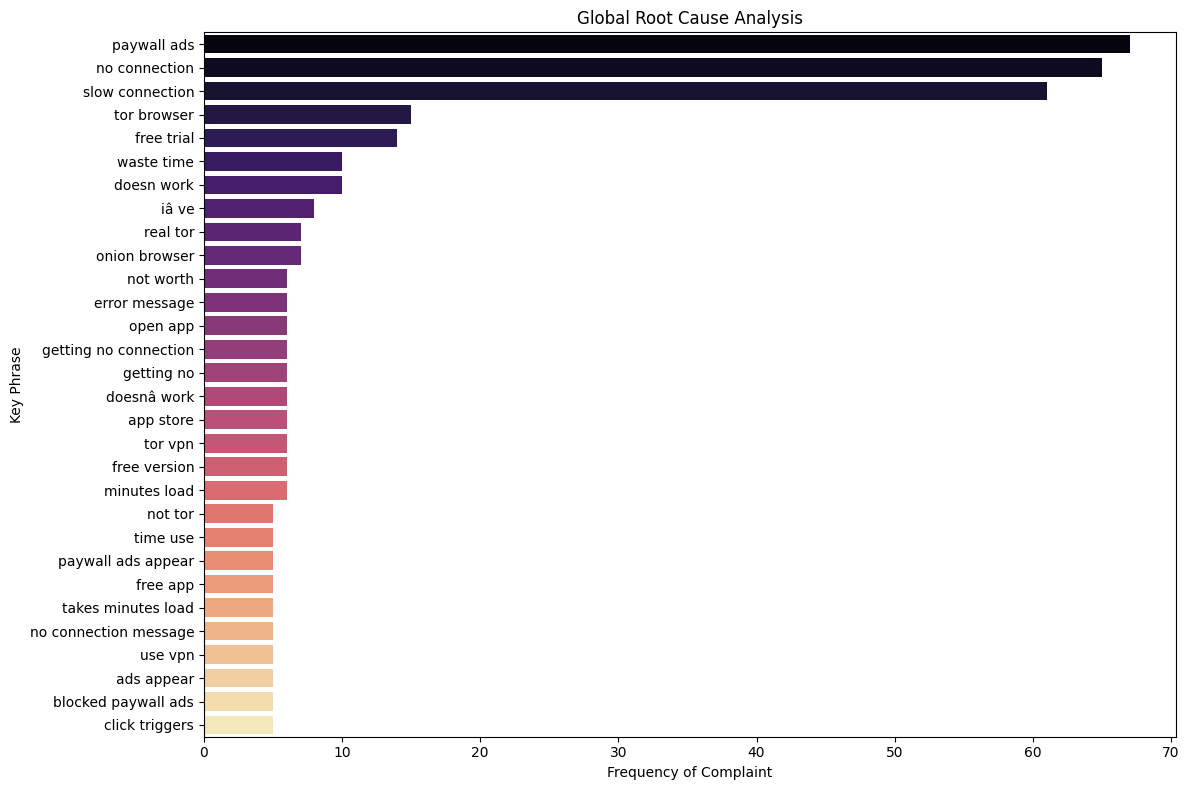

In [10]:
plt.figure(figsize=(12, 8))
top_phrases = phrase_counts.head(30)
sns.barplot(x=top_phrases.values, y=top_phrases.index, palette='magma')

plt.title('Global Root Cause Analysis')
plt.xlabel('Frequency of Complaint')
plt.ylabel('Key Phrase')
plt.tight_layout()
plt.show()